In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import seaborn as sns
import jinja2 as j2

In [8]:
df = pd.read_csv('data-69d3709338fdb705334215.csv')
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,6,1,0,0,0,0,0,1,0,Spain
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,5,0,0,0,0,1,1,0,Canada
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,5,2,0,0,0,0,0,0,0,USA
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/2014,0,10,...,2,7,0,0,0,0,0,0,0,Australia
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/2014,0,6,...,2,7,1,0,0,0,0,1,0,Spain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,3/7/2013,99,372,...,11,4,0,0,0,0,0,0,0,USA
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,0,0,0,0,0,0,0,Spain
2237,22,1976,Graduation,Divorced,46310.0,1,0,12/3/2012,99,185,...,5,8,0,0,0,0,0,0,0,Spain
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,10,3,0,0,0,0,0,0,0,India


In [9]:
df.dtypes

ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
 Income                float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntBakedProds            int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Response                 int64
Complain                 int64
Country                    str
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


In [11]:
df['Country'].value_counts()

Country
Spain           1095
Saudi Arabia     337
Canada           268
Australia        160
India            148
Germany          120
USA              109
Mexico             3
Name: count, dtype: int64

## Descrite variables 
1 .Year_birth. 

1 .Graduation. 

3 .Matrial_Status. 

4 .kidhome.

5 .Teenhome.

6 .Dt_Customer.

7 .Recency.

8 .AcceptedCmp3

9 .AcceptedCmp4

10 .AcceptedCmp5

11 .AcceptedCmp1

12 .Response

13 .Complain

14 .Country

## Continous Variables
1 .Income

2 .MntWines

3 .Mntfruits

4 .MntMeatProducts

5 .MntFishProducts

6 .MntBakedProds

7 .NumDealsPurchases

8 .NumCatalogPurchases


## Histogrammes et boxplots pour les ventes et montants des produits.

In [12]:
total_sales = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntBakedProds'].sum()
print(total_sales)
print("-------")
print("total products")
count_products = (df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']).sum()
print(count_products)

0       99581
1       99149
2       98830
3       98620
4       98666
        ...  
2235    99220
2236    98648
2237    98904
2238    99929
2239    99543
Length: 2240, dtype: int64
-------
total products
33291


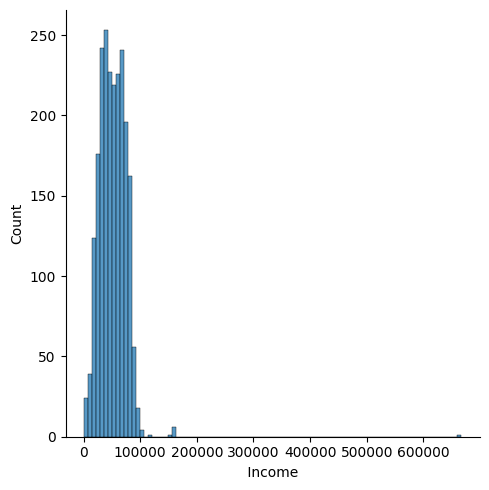

In [13]:
sns.displot(data = df ,x = " Income ")

<Axes: xlabel='Year_Birth'>

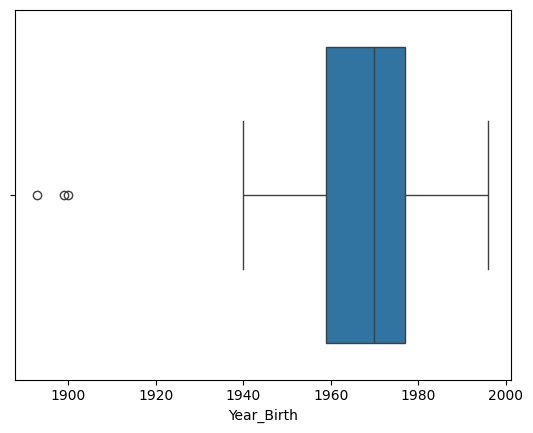

In [14]:
sns.boxplot(data = df, x = "Year_Birth")

## Bar charts pour le nombre de clients ayant accepté chaque campagne.

In [15]:
df['AcceptedCmp1'].duplicated().sum()
df.isna().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
 Income                24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntBakedProds           0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

#### just "Income" has a 24 misssing value 

## Check the impact of campaigns on sales

### 📌:its the same but in the first boxpot i filtred by country

Text(0.5, 0, 'Total Sales')

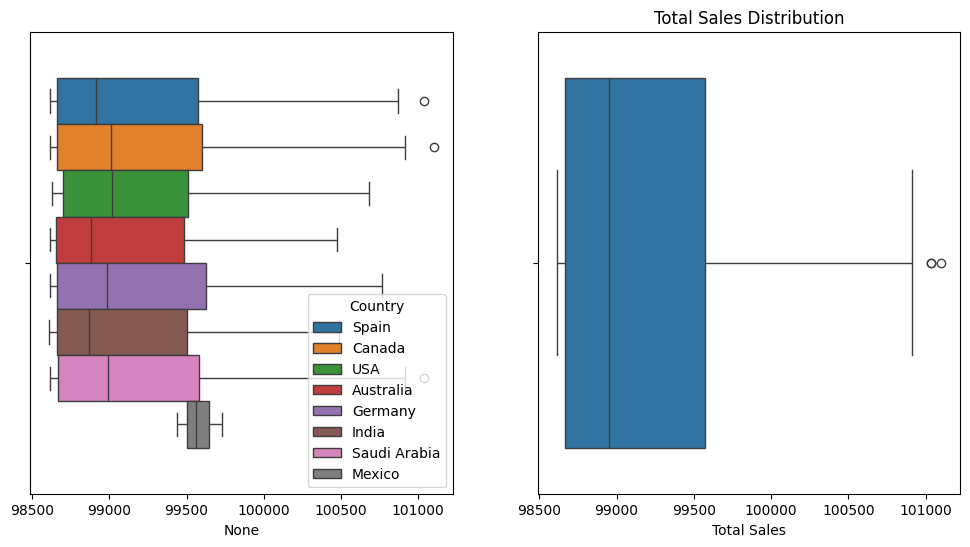

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.boxplot(x=total_sales, hue=df['Country'], ax=axes[0])
plt.title("Total Sales Distribution by Country")
plt.xlabel("Total Sales")
sns.boxplot(x=total_sales, ax=axes[1])
plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")

In [17]:
education_type=  df["Education"].unique()
education_type

<StringArray>
['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']
Length: 5, dtype: str

In [18]:
total_spending = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntBakedProds']
df['Total_Spending'] = total_spending
print(df['Total_Spending'])

0       1190
1        577
2        251
3         11
4         91
        ... 
2235     689
2236      55
2237     309
2238    1383
2239    1078
Name: Total_Spending, Length: 2240, dtype: int64


Text(0.5, 1.0, 'Relationship between Income and Total Spending')

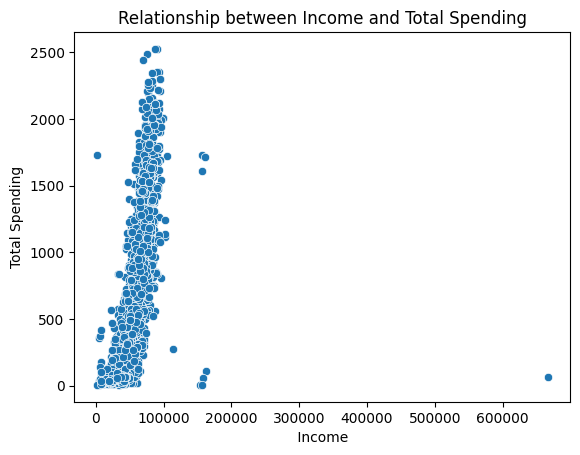

In [ ]:
sns.scatterplot(y=total_spending, x=df[" Income "])
plt.xlabel(" Income ") 
plt.ylabel("Total Spending")
plt.title("Relationship between Income and Total Spending")

## Matrix Correlation 
##### first filter by number cause of the function select_dtypes its not able the charactes 

### And thats a generraly Matrix


In [20]:
filter_nb = df.select_dtypes(include= 'number')
my_matrix = filter_nb.corr(method='pearson').round(2)
my_matrix.style.background_gradient(cmap='coolwarm')


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntBakedProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Total_Spending
ID,1.000000,0.000000,0.010000,0.000000,-0.000000,-0.050000,-0.020000,0.000000,-0.000000,-0.020000,-0.010000,-0.010000,-0.040000,-0.020000,-0.000000,-0.010000,-0.010000,-0.040000,-0.030000,-0.010000,-0.020000,-0.020000,-0.020000,0.030000,-0.020000
Year_Birth,0.000000,1.000000,-0.160000,0.230000,-0.350000,-0.020000,-0.160000,-0.020000,-0.030000,-0.040000,-0.020000,-0.060000,-0.060000,-0.150000,-0.120000,-0.130000,0.120000,0.060000,-0.060000,0.010000,-0.010000,-0.010000,0.020000,-0.030000,-0.110000
Income,0.010000,-0.160000,1.000000,-0.430000,0.020000,-0.000000,0.580000,0.430000,0.580000,0.440000,0.440000,0.330000,-0.080000,0.390000,0.590000,0.530000,-0.550000,-0.020000,0.180000,0.340000,0.280000,0.090000,0.130000,-0.030000,0.670000
Kidhome,0.000000,0.230000,-0.430000,1.000000,-0.040000,0.010000,-0.500000,-0.370000,-0.440000,-0.390000,-0.370000,-0.350000,0.220000,-0.360000,-0.500000,-0.500000,0.450000,0.010000,-0.160000,-0.210000,-0.170000,-0.080000,-0.080000,0.040000,-0.560000
Teenhome,-0.000000,-0.350000,0.020000,-0.040000,1.000000,0.020000,0.000000,-0.180000,-0.260000,-0.200000,-0.160000,-0.020000,0.390000,0.160000,-0.110000,0.050000,0.130000,-0.040000,0.040000,-0.190000,-0.140000,-0.020000,-0.150000,0.000000,-0.140000
Recency,-0.050000,-0.020000,-0.000000,0.010000,0.020000,1.000000,0.020000,-0.000000,0.020000,0.000000,0.020000,0.020000,-0.000000,-0.010000,0.030000,0.000000,-0.020000,-0.030000,0.020000,0.000000,-0.020000,-0.000000,-0.200000,0.010000,0.020000
MntWines,-0.020000,-0.160000,0.580000,-0.500000,0.000000,0.020000,1.000000,0.390000,0.560000,0.400000,0.390000,0.390000,0.010000,0.540000,0.640000,0.640000,-0.320000,0.060000,0.370000,0.470000,0.350000,0.210000,0.250000,-0.040000,0.890000
MntFruits,0.000000,-0.020000,0.430000,-0.370000,-0.180000,-0.000000,0.390000,1.000000,0.540000,0.590000,0.570000,0.390000,-0.130000,0.300000,0.490000,0.460000,-0.420000,0.010000,0.010000,0.220000,0.190000,-0.010000,0.130000,-0.010000,0.610000
MntMeatProducts,-0.000000,-0.030000,0.580000,-0.440000,-0.260000,0.020000,0.560000,0.540000,1.000000,0.570000,0.520000,0.350000,-0.120000,0.290000,0.720000,0.480000,-0.540000,0.020000,0.100000,0.370000,0.310000,0.040000,0.240000,-0.020000,0.840000
MntFishProducts,-0.020000,-0.040000,0.440000,-0.390000,-0.200000,0.000000,0.400000,0.590000,0.570000,1.000000,0.580000,0.420000,-0.140000,0.290000,0.530000,0.460000,-0.450000,0.000000,0.020000,0.200000,0.260000,0.000000,0.110000,-0.020000,0.640000


### now select the variables is possible already had a reltaion

In [21]:
x_wanted_data = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2']
y_wanted_data  = []

my_matrix = df[x_wanted_data].corr(method='kendall').round(2)
my_matrix.style.background_gradient(cmap='coolwarm')

,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2
AcceptedCmp3,1.000000,-0.080000,0.080000,0.090000,0.070000
AcceptedCmp4,-0.080000,1.000000,0.310000,0.250000,0.290000
AcceptedCmp5,0.080000,0.310000,1.000000,0.400000,0.220000
AcceptedCmp1,0.090000,0.250000,0.400000,1.000000,0.180000
AcceptedCmp2,0.070000,0.290000,0.220000,0.180000,1.000000


## Contingency Test by CHi2

<Axes: >

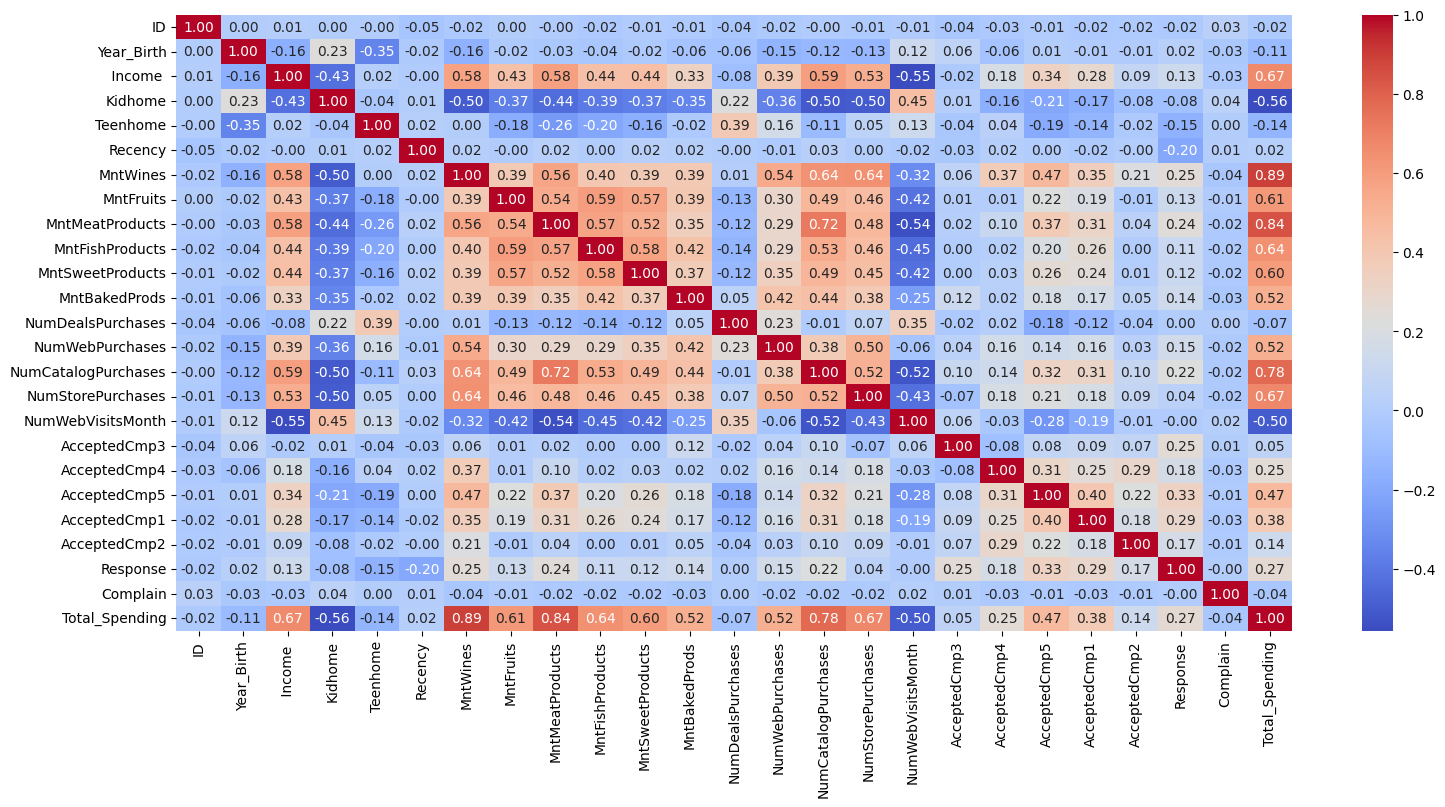

In [ ]:
plt.figure(figsize=(18,8))
plt.title("")
filter_nb = df.select_dtypes(include= 'number')
sns.heatmap (filter_nb.corr(), cmap = 'coolwarm' ,fmt=".2f", annot= True)
#my_matrix.style.background_gradient(cmap='coolwarm')